# Modeling and Results

This notebook trains the final classification models on `data/processed/feature_dataset.csv`. It compares combined and separate intraday/overnight models, evaluates multiple train-only resampling strategies, and tunes stronger tree-based models.

In [27]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    BASE_MODEL_FEATURES,
    MODEL_SCOPES,
    MODEL_SELECTION_METRIC,
    MODELS_DIR,
    RANDOM_STATE,
    TABLES_DIR,
    TARGET_COLUMN,
)
from src.data_loading import load_feature_data
from src.evaluation import evaluate_classifier, make_result_row
from src.modeling import (
    apply_resampling,
    available_resampling_strategies,
    base_model_specs,
    filter_model_scope,
    get_model_feature_columns,
    run_randomized_search,
    scale_split,
    chronological_train_val_test_split,
    tuned_model_specs,
)
from src.plots import plot_confusion_matrix, set_plot_style

set_plot_style()
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TUNING = True
TUNING_N_ITER = 5
SCORING = "f1"


## Load Final Feature Dataset

In [28]:
feature_df_pl = load_feature_data()
feature_df = feature_df_pl.to_pandas()

feature_cols = get_model_feature_columns(feature_df)
ticker_cols = [col for col in feature_cols if col.startswith("Ticker_")]
leakage_cols = {"Target_Return", "Target_Direction", "Target_Price", "Reference_Price"} & set(feature_cols)

print(f"Rows: {feature_df.shape[0]:,}")
print(f"Columns: {feature_df.shape[1]:,}")
print(f"Model feature columns: {len(feature_cols):,}")
print(f"Ticker dummy columns: {len(ticker_cols):,}")
print("Leakage columns in feature list:", sorted(leakage_cols))

display(feature_df.head())
display(feature_df.groupby(["Target_Type", TARGET_COLUMN]).size().reset_index(name="rows"))


Rows: 13,325
Columns: 70
Model feature columns: 55
Ticker dummy columns: 23
Leakage columns in feature list: []


,Target_Type,Ticker,Timestamp,Signal_Start,Signal_End,Target_Timestamp,Reference_Timestamp,Target_Horizon_Hours,Open,High,...,Ticker_MSFT,Ticker_MSTR,Ticker_NFLX,Ticker_NVDA,Ticker_PLTR,Ticker_QQQ,Ticker_RDDT,Ticker_SMCI,Ticker_SPY,Ticker_TSLA
0,intraday,$AAPL,2025-07-08 13:00:00+00:00,2025-07-08 13:00:00+00:00,2025-07-08 13:00:00+00:00,2025-07-08 14:00:00+00:00,2025-07-08 13:00:00+00:00,1.0,210.130005,210.490005,...,0,0,0,0,0,0,0,0,0,0
1,overnight,$AAPL,2025-07-09 12:00:00+00:00,2025-07-08 20:00:00+00:00,2025-07-09 12:00:00+00:00,2025-07-09 13:00:00+00:00,2025-07-08 19:00:00+00:00,1.0,210.035004,210.035004,...,0,0,0,0,0,0,0,0,0,0
2,intraday,$AAPL,2025-07-09 13:00:00+00:00,2025-07-09 13:00:00+00:00,2025-07-09 13:00:00+00:00,2025-07-09 14:00:00+00:00,2025-07-09 13:00:00+00:00,1.0,209.529999,210.899994,...,0,0,0,0,0,0,0,0,0,0
3,intraday,$AAPL,2025-07-09 15:00:00+00:00,2025-07-09 15:00:00+00:00,2025-07-09 15:00:00+00:00,2025-07-09 16:00:00+00:00,2025-07-09 15:00:00+00:00,1.0,207.809998,208.220001,...,0,0,0,0,0,0,0,0,0,0
4,intraday,$AAPL,2025-07-09 16:00:00+00:00,2025-07-09 16:00:00+00:00,2025-07-09 16:00:00+00:00,2025-07-09 17:00:00+00:00,2025-07-09 16:00:00+00:00,1.0,207.810394,209.044998,...,0,0,0,0,0,0,0,0,0,0


,Target_Type,Target_Direction,rows
0,intraday,0,4995
1,intraday,1,5001
2,overnight,0,1587
3,overnight,1,1742


## Available Resampling Strategies

Resampling is applied only to the training split. Validation and test data are never resampled. `smote` appears only if `imbalanced-learn` is installed.

In [29]:
resampling_strategies = available_resampling_strategies()
print("Strategies that will run:", resampling_strategies)

if "smote" not in resampling_strategies:
    print("SMOTE is unavailable until imbalanced-learn is installed. Random upsampling will still run.")


Strategies that will run: ['none', 'upsample', 'smote']


## Base Model Comparison

For each scope, we train Logistic Regression, Random Forest, and Histogram Gradient Boosting across all available resampling strategies. We choose the best resampling/model candidate by validation F1, then report test performance.

In [30]:
all_rows = []
trained_candidates = {}
scope_splits = {}

for scope in MODEL_SCOPES:
    scoped_df = filter_model_scope(feature_df, scope)
    split = chronological_train_val_test_split(scoped_df, feature_cols)
    scaled_split, scaler = scale_split(split)
    scope_splits[scope] = {"split": split, "scaled_split": scaled_split, "scaler": scaler}

    print(f"\n=== Scope: {scope} | rows={len(scoped_df):,} ===")
    print("Train/Val/Test:", scaled_split.X_train.shape, scaled_split.X_val.shape, scaled_split.X_test.shape)

    for resampling in resampling_strategies:
        try:
            X_train_resampled, y_train_resampled = apply_resampling(
                scaled_split.X_train,
                scaled_split.y_train,
                resampling,
                random_state=RANDOM_STATE,
            )
        except ImportError as exc:
            print(f"Skipping {resampling}: {exc}")
            continue

        for model_name, model in base_model_specs().items():
            model.fit(X_train_resampled, y_train_resampled)
            val_metrics = evaluate_classifier(model, scaled_split.X_val, scaled_split.y_val, label=model_name)
            test_metrics = evaluate_classifier(model, scaled_split.X_test, scaled_split.y_test, label=model_name)

            all_rows.append(make_result_row(
                scope=scope,
                model_name=model_name,
                resampling=resampling,
                split_name="validation",
                metrics=val_metrics,
            ))
            all_rows.append(make_result_row(
                scope=scope,
                model_name=model_name,
                resampling=resampling,
                split_name="test",
                metrics=test_metrics,
            ))
            trained_candidates[(scope, model_name, resampling)] = {
                "model": model,
                "scaler": scaler,
                "val_metrics": val_metrics,
                "test_metrics": test_metrics,
            }

results_df = pd.DataFrame(all_rows)
display(results_df.sort_values(["scope", "split", "f1"], ascending=[True, True, False]))

results_path = TABLES_DIR / "model_base_comparison.csv"
results_df.to_csv(results_path, index=False)
print(f"Saved base comparison to {results_path}")



=== Scope: combined | rows=13,325 ===
Train/Val/Test: (7995, 55) (2665, 55) (2665, 55)

=== Scope: intraday | rows=9,996 ===
Train/Val/Test: (5997, 55) (1999, 55) (2000, 55)

=== Scope: overnight | rows=3,329 ===
Train/Val/Test: (1997, 55) (666, 55) (666, 55)


,scope,model,resampling,split,precision,recall,f1,roc_auc,pr_auc
7,combined,logistic_regression,upsample,test,0.532309,0.726681,0.614491,0.526488,0.536410
13,combined,logistic_regression,smote,test,0.529695,0.715835,0.608856,0.532649,0.540855
1,combined,logistic_regression,none,test,0.528473,0.718004,0.608829,0.533352,0.541480
3,combined,random_forest,none,test,0.531061,0.698482,0.603373,0.529681,0.544692
15,combined,random_forest,smote,test,0.535510,0.676067,0.597635,0.530894,0.542928
5,combined,hist_gradient_boosting,none,test,0.528604,0.668113,0.590227,0.511834,0.536339
9,combined,random_forest,upsample,test,0.530506,0.660159,0.588273,0.527616,0.538652
17,combined,hist_gradient_boosting,smote,test,0.524818,0.626898,0.571334,0.516857,0.539577
11,combined,hist_gradient_boosting,upsample,test,0.530274,0.601591,0.563686,0.516880,0.540236
0,combined,logistic_regression,none,validation,0.486930,0.619011,0.545083,0.490194,0.469676


Saved base comparison to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\tables\model_base_comparison.csv


## Select Best Base Candidate by Validation F1

In [31]:
validation_results = results_df[results_df["split"] == "validation"].copy()
best_base_by_scope = (
    validation_results.sort_values(["scope", "f1", "pr_auc"], ascending=[True, False, False])
    .groupby("scope")
    .head(1)
    .reset_index(drop=True)
)

display(best_base_by_scope)

selected_resampling_by_scope = dict(zip(best_base_by_scope["scope"], best_base_by_scope["resampling"]))
print("Selected resampling by scope:", selected_resampling_by_scope)


,scope,model,resampling,split,precision,recall,f1,roc_auc,pr_auc
0,combined,logistic_regression,none,validation,0.486930,0.619011,0.545083,0.490194,0.469676
1,intraday,logistic_regression,none,validation,0.496683,0.613101,0.548786,0.504887,0.501477
2,overnight,hist_gradient_boosting,none,validation,0.562500,0.682584,0.616751,0.536163,0.567194


Selected resampling by scope: {'combined': 'none', 'intraday': 'none', 'overnight': 'none'}


## Hyperparameter Tuning

For each scope, tune the two stronger model families using the selected resampling strategy from validation. The test set remains untouched until final evaluation.

In [32]:
tuned_rows = []
tuned_models = {}

if RUN_TUNING:
    for scope in MODEL_SCOPES:
        selected_resampling = selected_resampling_by_scope[scope]
        scaled_split = scope_splits[scope]["scaled_split"]
        scaler = scope_splits[scope]["scaler"]
        X_train_resampled, y_train_resampled = apply_resampling(
            scaled_split.X_train,
            scaled_split.y_train,
            selected_resampling,
            random_state=RANDOM_STATE,
        )

        print(f"\n=== Tuning scope: {scope} | resampling={selected_resampling} ===")
        for model_name, (estimator, params) in tuned_model_specs().items():
            search = run_randomized_search(
                estimator,
                params,
                X_train_resampled,
                y_train_resampled,
                n_iter=TUNING_N_ITER,
                scoring=SCORING,
                random_state=RANDOM_STATE,
            )
            model = search.best_estimator_
            val_metrics = evaluate_classifier(model, scaled_split.X_val, scaled_split.y_val, label=model_name)
            test_metrics = evaluate_classifier(model, scaled_split.X_test, scaled_split.y_test, label=model_name)

            tuned_rows.append(make_result_row(
                scope=scope,
                model_name=model_name,
                resampling=selected_resampling,
                split_name="validation",
                metrics=val_metrics,
            ))
            tuned_rows.append(make_result_row(
                scope=scope,
                model_name=model_name,
                resampling=selected_resampling,
                split_name="test",
                metrics=test_metrics,
            ))
            tuned_models[(scope, model_name, selected_resampling)] = {
                "model": model,
                "scaler": scaler,
                "search": search,
                "val_metrics": val_metrics,
                "test_metrics": test_metrics,
                "best_params": search.best_params_,
            }
            print(model_name, "best params:", search.best_params_)

    tuned_results_df = pd.DataFrame(tuned_rows)
else:
    tuned_results_df = pd.DataFrame(columns=results_df.columns)

display(tuned_results_df.sort_values(["scope", "split", "f1"], ascending=[True, True, False]))

tuned_path = TABLES_DIR / "model_tuned_comparison.csv"
tuned_results_df.to_csv(tuned_path, index=False)
print(f"Saved tuned comparison to {tuned_path}")



=== Tuning scope: combined | resampling=none ===
random_forest_tuned best params: {'n_estimators': 250, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 6}
hist_gradient_boosting_tuned best params: {'max_leaf_nodes': 31, 'max_iter': 100, 'learning_rate': 0.05, 'l2_regularization': 0.1}

=== Tuning scope: intraday | resampling=none ===
random_forest_tuned best params: {'n_estimators': 250, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 6}
hist_gradient_boosting_tuned best params: {'max_leaf_nodes': 31, 'max_iter': 100, 'learning_rate': 0.08, 'l2_regularization': 0.0}

=== Tuning scope: overnight | resampling=none ===
random_forest_tuned best params: {'n_estimators': 400, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
hist_gradient_boosting_tuned best params: {'max_leaf_nodes': 31, 'max_iter': 300, 'learning_rate': 0.08, 'l2_regularization': 0.1}


,scope,model,resampling,split,precision,recall,f1,roc_auc,pr_auc
3,combined,hist_gradient_boosting_tuned,none,test,0.527382,0.696312,0.600187,0.521989,0.544458
1,combined,random_forest_tuned,none,test,0.530958,0.657267,0.587399,0.535162,0.547565
2,combined,hist_gradient_boosting_tuned,none,validation,0.474598,0.570325,0.518077,0.471196,0.460544
0,combined,random_forest_tuned,none,validation,0.474525,0.482226,0.478344,0.477773,0.469387
5,intraday,random_forest_tuned,none,test,0.521739,0.729730,0.608451,0.514667,0.540381
7,intraday,hist_gradient_boosting_tuned,none,test,0.508846,0.583012,0.543410,0.493679,0.514780
4,intraday,random_forest_tuned,none,validation,0.480680,0.636643,0.547776,0.486459,0.483333
6,intraday,hist_gradient_boosting_tuned,none,validation,0.487132,0.542477,0.513317,0.496665,0.497083
9,overnight,random_forest_tuned,none,test,0.508065,0.765957,0.610909,0.513064,0.503251
11,overnight,hist_gradient_boosting_tuned,none,test,0.480088,0.659574,0.555698,0.479810,0.480760


Saved tuned comparison to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\tables\model_tuned_comparison.csv


## Final Model Selection

In [33]:
final_results_df = pd.concat([results_df, tuned_results_df], ignore_index=True)
final_validation = final_results_df[final_results_df["split"] == "validation"].copy()
final_test = final_results_df[final_results_df["split"] == "test"].copy()

best_by_scope = (
    final_validation.sort_values(["scope", "f1", "pr_auc"], ascending=[True, False, False])
    .groupby("scope")
    .head(1)
    .reset_index(drop=True)
)

display(best_by_scope)

final_summary_rows = []
best_artifacts = {}
for row in best_by_scope.itertuples(index=False):
    key = (row.scope, row.model, row.resampling)
    artifact = tuned_models.get(key) or trained_candidates.get(key)
    if artifact is None:
        raise KeyError(key)
    test_row = final_test[
        (final_test["scope"] == row.scope)
        & (final_test["model"] == row.model)
        & (final_test["resampling"] == row.resampling)
    ].iloc[0]
    final_summary_rows.append(test_row.to_dict())
    best_artifacts[row.scope] = artifact

final_summary_df = pd.DataFrame(final_summary_rows)
display(final_summary_df)

final_results_path = TABLES_DIR / "model_final_results.csv"
final_results_df.to_csv(final_results_path, index=False)
final_summary_path = TABLES_DIR / "model_final_summary.csv"
final_summary_df.to_csv(final_summary_path, index=False)
print(f"Saved all results to {final_results_path}")
print(f"Saved final summary to {final_summary_path}")


,scope,model,resampling,split,precision,recall,f1,roc_auc,pr_auc
0,combined,logistic_regression,none,validation,0.486930,0.619011,0.545083,0.490194,0.469676
1,intraday,logistic_regression,none,validation,0.496683,0.613101,0.548786,0.504887,0.501477
2,overnight,random_forest_tuned,none,validation,0.558242,0.713483,0.626387,0.540486,0.565072


,scope,model,resampling,split,precision,recall,f1,roc_auc,pr_auc
0,combined,logistic_regression,none,test,0.528473,0.718004,0.608829,0.533352,0.541480
1,intraday,logistic_regression,none,test,0.525609,0.604247,0.562191,0.504710,0.525151
2,overnight,random_forest_tuned,none,test,0.508065,0.765957,0.610909,0.513064,0.503251


Saved all results to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\tables\model_final_results.csv
Saved final summary to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\tables\model_final_summary.csv


## Confusion Matrices for Selected Models

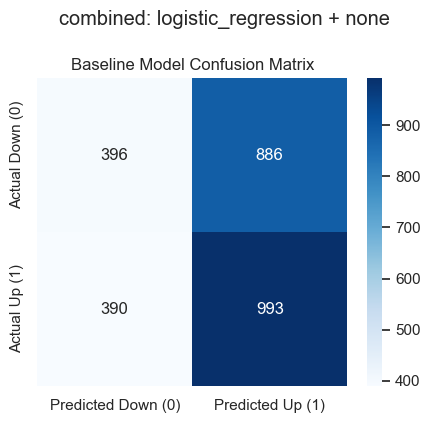

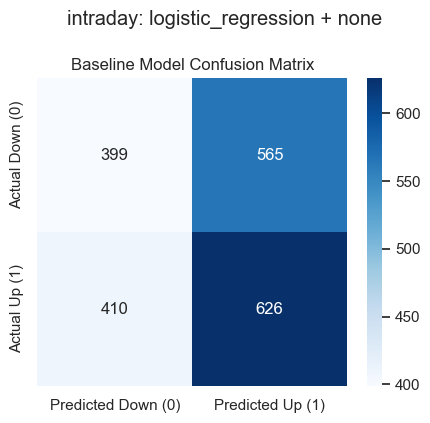

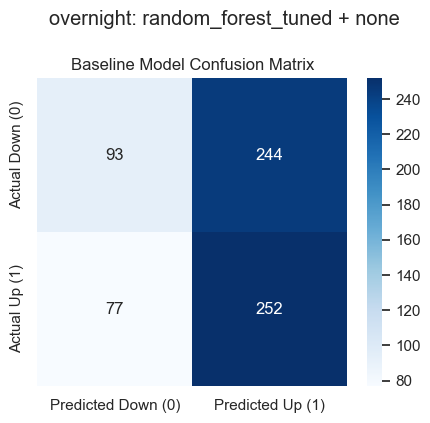

In [34]:
for row in best_by_scope.itertuples(index=False):
    artifact = best_artifacts[row.scope]
    split = scope_splits[row.scope]["scaled_split"]
    metrics = evaluate_classifier(artifact["model"], split.X_test, split.y_test, label=row.model)
    fig = plot_confusion_matrix(metrics["confusion_matrix"])
    fig.suptitle(f"{row.scope}: {row.model} + {row.resampling}", y=1.05)
    plt.show()


## Feature Importance

Random Forest exposes native feature importance. Histogram Gradient Boosting does not expose a simple impurity-based importance in this sklearn version, so we report importances when available and use model results otherwise.

combined: logistic_regression does not expose feature_importances_.
intraday: logistic_regression does not expose feature_importances_.


,feature,importance
7,Hourly_Return,0.051963
19,Sentiment_EMA_24,0.045110
18,Sentiment_EMA_4,0.044457
20,Sentiment_Z_24,0.043320
25,Post_Count_Z_24,0.043075
16,Sentiment_Min,0.042588
12,Volume_Z_24,0.041723
17,Sentiment_Max,0.041528
14,Sentiment_Median,0.040743
8,High_Low_Range,0.040164


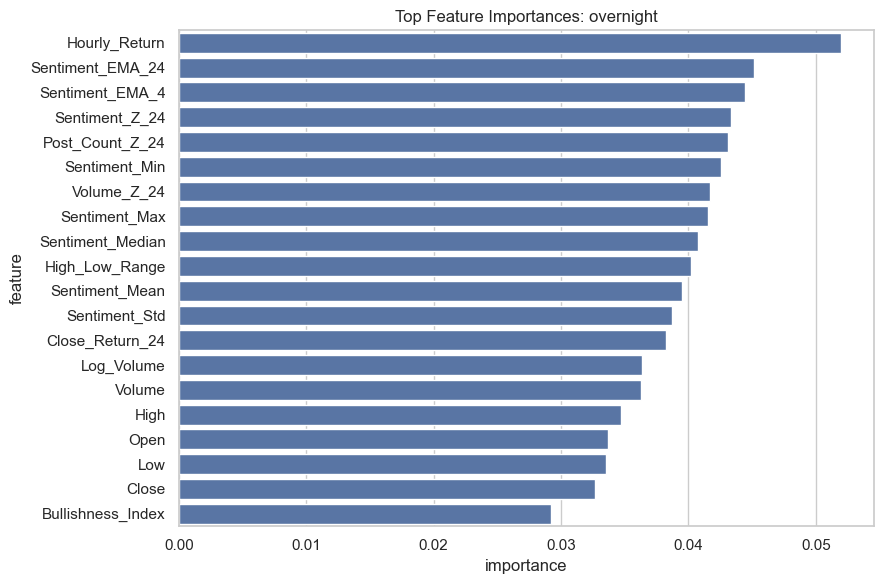

In [35]:
for row in best_by_scope.itertuples(index=False):
    artifact = best_artifacts[row.scope]
    model = artifact["model"]
    if not hasattr(model, "feature_importances_"):
        print(f"{row.scope}: {row.model} does not expose feature_importances_.")
        continue

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).head(20)

    display(importance_df)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Top Feature Importances: {row.scope}")
    plt.tight_layout()
    plt.show()


## Save Selected Models

These artifacts can be loaded by the dashboard without retraining.

In [36]:
for row in best_by_scope.itertuples(index=False):
    artifact = best_artifacts[row.scope]
    payload = {
        "scope": row.scope,
        "model_name": row.model,
        "resampling": row.resampling,
        "model": artifact["model"],
        "scaler": artifact["scaler"],
        "feature_cols": feature_cols,
    }
    model_path = MODELS_DIR / f"best_{row.scope}_model.joblib"
    joblib.dump(payload, model_path)
    print(f"Saved {row.scope} model to {model_path}")


Saved combined model to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\models\best_combined_model.joblib
Saved intraday model to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\models\best_intraday_model.joblib
Saved overnight model to C:\Users\dpnim\Documents\cis 2450\cis-2450-final-proj\outputs\models\best_overnight_model.joblib


## Modeling Notes

- Scaling is fit on training data only.
- Random upsampling and SMOTE are applied to training data only.
- Validation drives model/resampling selection.
- Test metrics are reported only after the model choice is made.
- The dashboard should load the saved `best_*_model.joblib` artifacts and the result CSVs in `outputs/tables/`.